In [339]:
import numpy as np

In [340]:
background_noise = 528  # counts
high_counts = np.array(
    [
        3869,
        3916,
        3767,
        3900,
        3866,
        3679,
        3844,
        3841,
        3864,
        3796,
        3833,
        3800,
        3848,
        3894,
        3765,
        3799,
        3790,
        3810,
        3891,
        3808,
        3866,
        3759,
        3886,
        3749,
        3918,
        3826,
        3964,
        3843,
        3907,
        3858,
        3810,
        3713,
        3983,
        3754,
        3831,
        3878,
        3755,
        3860,
        3887,
        3801,
        3882,
        3799,
        3887,
        3807,
        3796,
        3850,
        3807,
        3865,
        3896,
        3812,
        3966,
        3837,
        3848,
        3827,
        3813,
        3848,
        3788,
        3785,
        3787,
        3798,
        3863,
        3839,
        3769,
        3844,
        3954,
        3778,
        3830,
        3814,
        3862,
        3782,
        3877,
        3864,
        3846,
        3808,
        3904,
        3769,
        3818,
        3826,
        3914,
        4022,
        3738,
        3890,
        3827,
        3888,
        3821,
        3843,
        3912,
        3837,
        3782,
        3823,
        3844,
        3826,
        3821,
        3760,
        3836,
        3905,
        3827,
        3792,
        3883,
        3813,
    ]
)  # counts
low_counts = np.array(
    [
        4,
        4,
        1,
        1,
        2,
        3,
        1,
        3,
        6,
        3,
        2,
        7,
        3,
        3,
        3,
        3,
        4,
        4,
        3,
        4,
        8,
        1,
        3,
        3,
        3,
        5,
        1,
        4,
        4,
        5,
        3,
        4,
        2,
        2,
        3,
        6,
        6,
        5,
        6,
        3,
        5,
        5,
        3,
        3,
        2,
        0,
        1,
        4,
        7,
        2,
        4,
        3,
        3,
        4,
        7,
        5,
        5,
        6,
        7,
        4,
        2,
        6,
        4,
        6,
        2,
        3,
        5,
        4,
        3,
        2,
        1,
        4,
        2,
        5,
        2,
        7,
        2,
        2,
        1,
        3,
        4,
        7,
        5,
        7,
        3,
        7,
        3,
        6,
        6,
        4,
        2,
        6,
        1,
        2,
        7,
        5,
        3,
        5,
        2,
        5,
    ]
)  # counts

In [341]:
import pandas as pd

lowdf = pd.DataFrame(low_counts, columns=["Low Counts"])
highdf = pd.DataFrame(high_counts, columns=["High Counts"])


In [342]:
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm
from scipy.optimize import curve_fit

In [343]:
n_low_bins = 8
n_high_bins = 9
lowhist, lowbins = np.histogram(low_counts, bins=n_low_bins)
highhist, highbins = np.histogram(high_counts, bins=n_high_bins)

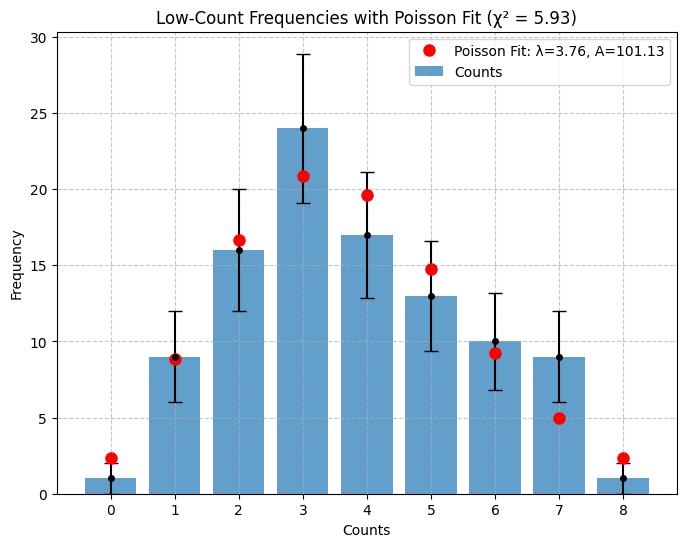

In [361]:
# Obtain bin centers for low counts that align with integers
bin_centers = np.arange(np.floor(low_counts.min()), np.ceil(low_counts.max()) + 1)
n, _ = np.histogram(
    low_counts,
    bins=np.arange(np.floor(low_counts.min()) - 0.5, np.ceil(low_counts.max()) + 1.5),
)

low_unc = np.sqrt(low_counts)


# Define Poisson function for curve fitting
def poisson_function(x, A, lam):
    from scipy.special import factorial

    return A * np.power(lam, x) * np.exp(-lam) / factorial(x)


# Estimate initial parameters
initial_A = np.max(n)
initial_lam = np.mean(low_counts)

# Perform curve fitting
popt, _ = curve_fit(poisson_function, bin_centers, n, p0=[initial_A, initial_lam])

# Calculate chi-squared
expected = poisson_function(bin_centers, *popt)
chi_squared = np.sum((n - expected) ** 2 / expected)

# Plot the histogram of low counts
plt.figure(figsize=(8, 6))
n_unc = np.sqrt(n)
plt.bar(bin_centers, n, alpha=0.7, label="Counts")
plt.errorbar(
    bin_centers,
    n,
    yerr=n_unc,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=5,
    markersize=4,
)
plt.title(f"Low-Count Frequencies with Poisson Fit (χ² = {chi_squared:.2f})")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)

# Plot the Poisson distribution fit as discrete points
x_fit = np.arange(bin_centers.min(), bin_centers.max() + 1)
plt.plot(
    x_fit,
    poisson_function(x_fit, *popt),
    "ro",
    markersize=8,
    label=f"Poisson Fit: λ={popt[1]:.2f}, A={popt[0]:.2f}",
)

plt.legend()
plt.xticks(np.arange(np.floor(low_counts.min()), np.ceil(low_counts.max()) + 1, 1))
plt.savefig("low_counts_histogram.png")
plt.show()

In [363]:
lowdf.mean()

Low Counts    3.77
dtype: float64

In [371]:
sdom = lowdf.std(ddof=1) / np.sqrt(len(low_counts))
sdom

Low Counts    0.182494
dtype: float64

In [372]:
(lowdf.std(ddof=1) ** 2 - lowdf.mean()) / sdom

Low Counts   -2.408825
dtype: float64

In [375]:
(lowdf.std(ddof=1) ** 2)

Low Counts    3.330404
dtype: float64

In [376]:
(3.77 - 3.33) / 0.18

2.444444444444444

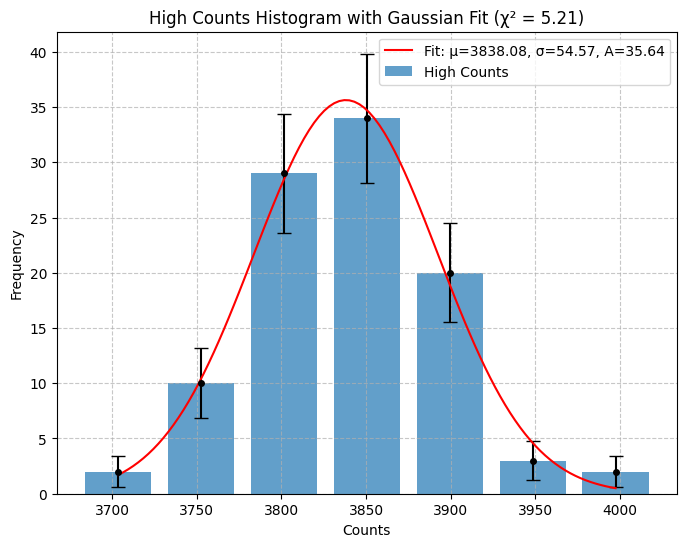

In [362]:
# Plot histogram of high counts with user-defined number of bins
n_high_plot_bins = 7  # matching previous histogram bin count, but user can adjust
plt.figure(figsize=(8, 6))

# Create histogram and get bin centers and heights
high_hist, high_plot_bins = np.histogram(high_counts, bins=n_high_plot_bins)
bin_centers = 0.5 * (high_plot_bins[1:] + high_plot_bins[:-1])

high_unc = np.sqrt(high_counts)

# Plot the histogram with wider bars
high_hist_unc = np.sqrt(high_hist)
plt.bar(
    bin_centers,
    high_hist,
    alpha=0.7,
    label="High Counts",
    width=(high_plot_bins[1] - high_plot_bins[0]) * 0.8,
)
plt.errorbar(
    bin_centers,
    high_hist,
    yerr=high_hist_unc,
    fmt="o",
    color="black",
    ecolor="black",
    capsize=5,
    markersize=4,
)


# Define Gaussian function for curve fitting
def gaussian_function(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma**2))


# Perform curve fitting
initial_A = np.max(high_hist)
initial_mu = np.mean(high_counts)
initial_sigma = np.std(high_counts)

popt, _ = curve_fit(
    gaussian_function, bin_centers, high_hist, p0=[initial_A, initial_mu, initial_sigma]
)

# Unpack optimized parameters
A_fit, mu_fit, sigma_fit = popt

# Calculate chi-squared
expected = gaussian_function(bin_centers, *popt)
chi_squared = np.sum((high_hist - expected) ** 2 / expected)

# Plot the fitted curve
x_fit = np.linspace(bin_centers.min(), bin_centers.max(), 100)
plt.plot(
    x_fit,
    gaussian_function(x_fit, *popt),
    "r-",
    label=f"Fit: μ={mu_fit:.2f}, σ={sigma_fit:.2f}, A={A_fit:.2f}",
)

plt.title(f"High Counts Histogram with Gaussian Fit (χ² = {chi_squared:.2f})")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.savefig("high_counts_histogram.png")
plt.show()


In [373]:
highdf.mean()

High Counts    3837.77
dtype: float64

In [374]:
highdf.std(ddof=1) / np.sqrt(len(high_counts))

High Counts    5.738033
dtype: float64

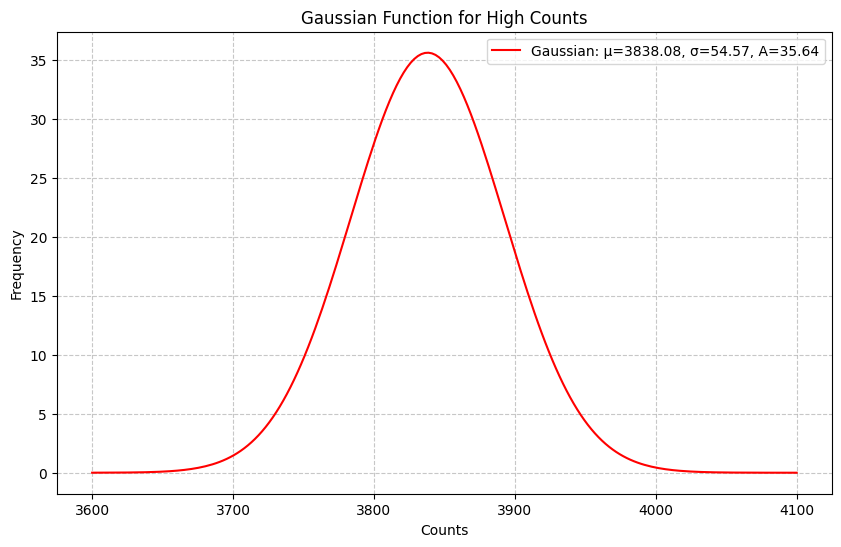

In [346]:
# Plot the Gaussian function within the specified range
x_gaussian = np.linspace(3600, 4100, 200)
y_gaussian = gaussian_function(x_gaussian, *popt)

plt.figure(figsize=(10, 6))
plt.plot(
    x_gaussian,
    y_gaussian,
    "r-",
    label=f"Gaussian: μ={mu_fit:.2f}, σ={sigma_fit:.2f}, A={A_fit:.2f}",
)
plt.title("Gaussian Function for High Counts")
plt.xlabel("Counts")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.show()


In [347]:
sample_mean = highdf.mean().item()
sample_std = highdf.std(ddof=1).item()

In [348]:
# By explicit counting:
def sigma_1(x, sigma, mu):
    return (x > (mu - sigma)) * (x < (mu + sigma))


def sigma_2(x, sigma, mu):
    return (x > (mu - 2 * sigma)) * (x < (mu + 2 * sigma))


print(
    "Proportion of counts in σ1:",
    sigma_1(highdf, sample_std, sample_mean).sum() / len(highdf),
)
print(
    "Proportion of counts in σ2:",
    sigma_2(highdf, sample_std, sample_mean).sum() / len(highdf),
)

Proportion of counts in σ1: High Counts    0.73
dtype: float64
Proportion of counts in σ2: High Counts    0.93
dtype: float64


In [349]:
print("True high count mean:", highdf.mean())

True high count mean: High Counts    3837.77
dtype: float64


In [350]:
sample_mean
sample_std

57.38032869557407

In [379]:
def generic_integral(func, a, b):
    """
    Numerically integrate a function between generic bounds a and b

    Parameters:
    -----------
    func : callable
        Function to integrate
    a : float
        Lower bound of integration
    b : float
        Upper bound of integration

    Returns:
    --------
    float
        Integral of the specified function from a to b
    """
    from scipy import integrate

    integral, _ = integrate.quad(
        func,
        a,
        b,
    )
    return integral


bin_width = high_plot_bins[1] - high_plot_bins[0]
print(bin_width)

in_1_sigma_counts = generic_integral(
    lambda x: gaussian_function(x, *popt),
    sample_mean - sample_std,
    sample_mean + sample_std,
) / (bin_width)

in_1_sigma_count_unc = np.sqrt(in_1_sigma_counts)

in_2_sigma_counts = generic_integral(
    lambda x: gaussian_function(x, *popt),
    sample_mean - 2 * sample_std,
    sample_mean + 2 * sample_std,
) / (bin_width)

in_2_sigma_count_unc = np.sqrt(in_2_sigma_counts)

in_1_sigma_prop = in_1_sigma_counts / len(high_counts)
in_2_sigma_prop = in_2_sigma_counts / len(high_counts)

# This is an application of the quotient propagation

in_1_sigma_prop_unc = in_1_sigma_prop * np.sqrt(
    (in_1_sigma_count_unc / in_1_sigma_counts) ** 2
)
in_2_sigma_prop_unc = in_2_sigma_prop * np.sqrt(
    (in_2_sigma_count_unc / in_2_sigma_counts) ** 2
)

print(in_1_sigma_prop, in_2_sigma_prop)
print(in_1_sigma_prop_unc, in_2_sigma_prop_unc)

49.0
0.7033092765357232 0.9595737414632246
0.08386353656600247 0.09795783488130107


$$
\delta[p] = p \cdot \sqrt{\left ( \frac{c}{\delta c} \right )^2}
$$


In [352]:
total_area = generic_integral(
    lambda x: gaussian_function(x, *popt), mu_fit - sigma_fit, mu_fit + sigma_fit
)
total_area

3328.022004860682

In [353]:
((highdf > 3838) * (highdf < 3838)).sum()

High Counts    0
dtype: int64

In [354]:
(highdf < 3838).sum()

High Counts    53
dtype: int64

In [355]:
(highdf > 3838).sum()

High Counts    47
dtype: int64

In [356]:
expectations = gaussian_function(bin_centers, *popt)
observations = high_hist
chi_squared = np.sum((observations - expectations) ** 2 / expectations)
print(chi_squared)

5.214255645518428


In [357]:
len(high_hist) == len(expectations)

True

In [358]:
gaussian_function(3825, *popt)

np.float64(34.62701212237559)

In [377]:
3838 / 100

38.38

In [378]:
38.38 * np.sqrt((6 / 3838) ** 2 + (0.01 / 10) ** 2)

np.float64(0.07122516690047136)